# Introduction
>**Topic**: **"Toxic Comments Classification"**


> **Problem Statement**:

Toxic comments on online platforms can lead to harassment, discrimination, and a decline in the quality of online discussions. Detecting and classifying toxic comments is a challenging task due to the imbalance between toxic and non-toxic data, subtle language variations, and context-dependent expressions. The goal of this project is to build an effective **binary classification** model that can accurately distinguish between toxic and non-toxic comments.

> **Objective**:

* Develop and evaluate baseline (Logistic Regression) and advanced (XGBoost) models for toxicity detection.

* Address class imbalance (≈90% non-toxic vs 10% toxic) using appropriate weighting techniques.

* Tune the classification threshold to optimize the F1-score, which balances precision and recall.

* Compare both models in terms of precision, recall, F1-score, AUC, and accuracy, and visualize how these metrics vary with threshold changes.



# Setup

* Import dataset from Kaggle

In [ ]:
!pip -q install kaggle xgboost scikit-learn pandas numpy joblib


- Create new token from Kaggle so as long as you are with the token from Kaggle, then you can execute this project anytime you want

In [ ]:
from google.colab import files
files.upload()  # select kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"minjungkoo","key":"5d2051a686f49a0f75e2eff6eea2c1e9"}'}

In [ ]:
import os, shutil
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)


In [ ]:
!kaggle datasets list -s toxic


ref                                                           title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
reihanenamdari/youtube-toxicity-data                          Youtube toxic comments                                  99167  2022-08-06 00:08:41.833000           4539         76  1.0              
fizzbuzz/cleaned-toxic-comments                               Cleaned Toxic Comments                               45799147  2018-03-12 05:12:31.550000           4196         88  0.8235294        
julian3833/jigsaw-toxic-comment-classification-challenge      jigsaw-toxic-comment-classification-challenge        55956177  2021-11-11 04:08:25.700000          13231        247  0.7058824        
prokopyev/armor

In [ ]:
# assumes your Kaggle API key is already set up
!mkdir -p /content/jigsaw_ml
!kaggle datasets download -d julian3833/jigsaw-multilingual-toxic-comment-classification -p /content/jigsaw_ml -q
!unzip -q -o /content/jigsaw_ml/jigsaw-multilingual-toxic-comment-classification.zip -d /content/jigsaw_ml
!ls -lh /content/jigsaw_ml | sed -n '1,120p'


Dataset URL: https://www.kaggle.com/datasets/julian3833/jigsaw-multilingual-toxic-comment-classification
License(s): CC0-1.0
total 5.8G
-rw-r--r-- 1 root root 1.1G Nov 14  2021 jigsaw-multilingual-toxic-comment-classification.zip
-rw-r--r-- 1 root root  92M Nov 14  2021 jigsaw-toxic-comment-train.csv
-rw-r--r-- 1 root root 388M Nov 14  2021 jigsaw-toxic-comment-train-processed-seqlen128.csv
-rw-r--r-- 1 root root 821M Nov 14  2021 jigsaw-unintended-bias-train.csv
-rw-r--r-- 1 root root 3.3G Nov 14  2021 jigsaw-unintended-bias-train-processed-seqlen128.csv
-rw-r--r-- 1 root root 613K Nov 14  2021 sample_submission.csv
-rw-r--r-- 1 root root  28M Nov 14  2021 test.csv
-rw-r--r-- 1 root root 488K Nov 14  2021 test_labels.csv
-rw-r--r-- 1 root root 118M Nov 14  2021 test-processed-seqlen128.csv
-rw-r--r-- 1 root root 3.1M Nov 14  2021 validation.csv
-rw-r--r-- 1 root root  15M Nov 14  2021 validation-processed-seqlen128.csv


# Data Preprocessing

In [ ]:
import pandas as pd
PATH = "/content/jigsaw_ml/jigsaw-toxic-comment-train.csv"

df = pd.read_csv(PATH)
df["comment_text"] = df["comment_text"].fillna("")
df["toxic"] = df["toxic"].astype(int)

print(df.shape)
df.head(3)
df["toxic"].value_counts(normalize=True)  # class balance check (Toxic/Non-toxic), which shows dataset is imbalanced


(223549, 8)


,proportion
toxic,
0,0.904343
1,0.095657


##  Split the Dataset into 3 sections

- Train (80%)
- Validation (10%)
- Test (10%)

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

# 0) Load your single CSV
PATH = "/content/jigsaw_ml/jigsaw-toxic-comment-train.csv"
df = pd.read_csv(PATH)
df["comment_text"] = df["comment_text"].fillna("")
df["toxic"] = df["toxic"].astype(int)

# 1) First split: Train (80%) vs Temp (20%) using stratification

# Create a Stratified ShuffleSplit object that preserves the class ratio
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(sss1.split(df["comment_text"], df["toxic"]))
train = df.iloc[train_idx].reset_index(drop=True)
temp  = df.iloc[temp_idx].reset_index(drop=True)

# 2) Second split: from Temp (20%), make Val (10%) and Test (10%)

#Split the temporary set in half (50/50) - each becomes 10% of total data
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)

# Split indices again while keeping same toxic ratio
val_idx, test_idx = next(sss2.split(temp["comment_text"], temp["toxic"]))

# Create validation and test sets
val  = temp.iloc[val_idx].reset_index(drop=True)
test = temp.iloc[test_idx].reset_index(drop=True)

# 3) Sanity checks: proportion + counts (no zero-positive sets)
def summarize(name, d):
    p = d["toxic"].mean()
    cnt1 = int(d["toxic"].sum())  # Count of positive (toxic) samples
    cnt0 = len(d) - cnt1          # Count of negative (non-toxic) samples

    # Print dataset summary (name, size, percentage, counts)
    print(f"{name:>5} | n={len(d):7d} | toxic%={p*100:5.2f} | pos={cnt1} | neg={cnt0}")

# Display summary for each split
summarize("train", train)
summarize("val",   val)
summarize("test",  test)

assert train["toxic"].sum() > 0 and val["toxic"].sum() > 0 and test["toxic"].sum() > 0, "One split has zero toxic samples!"


train | n= 178839 | toxic%= 9.57 | pos=17107 | neg=161732
  val | n=  22355 | toxic%= 9.57 | pos=2139 | neg=20216
 test | n=  22355 | toxic%= 9.56 | pos=2138 | neg=20217


In [ ]:
import os

# Make a folder for splits
os.makedirs("/content/splits", exist_ok=True)

# Save to CSV
train.to_csv("/content/splits/train.csv", index=False)
val.to_csv("/content/splits/val.csv", index=False)
test.to_csv("/content/splits/test.csv", index=False)

# Quick check
!ls -lh /content/splits


total 92M
-rw-r--r-- 1 root root 9.1M Oct  8 02:04 test.csv
-rw-r--r-- 1 root root  73M Oct  8 02:04 train.csv
-rw-r--r-- 1 root root 9.3M Oct  8 02:04 val.csv


> Load the saved splits

In [ ]:
import pandas as pd, numpy as np
train = pd.read_csv("/content/splits/train.csv")
val   = pd.read_csv("/content/splits/val.csv")
test  = pd.read_csv("/content/splits/test.csv")

for name, df in [("train",train),("val",val),("test",test)]:
    print(name, df.shape, "toxic%:", round(df['toxic'].mean()*100,2))


train (178839, 8) toxic%: 9.57
val (22355, 8) toxic%: 9.57
test (22355, 8) toxic%: 9.56


## Vectorize text with TF-IDF (fit on train only)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract target labels (0 or 1) from each split and convert to NumPy arrays
y_train = train["toxic"].astype(int).values
y_val   = val["toxic"].astype(int).values
y_test  = test["toxic"].astype(int).values


# Initialise a TF-IDF vectorizer to convert text into numerical features
tfidf = TfidfVectorizer(
    lowercase=True,         # Convert all text to lowercase before processing
    ngram_range=(1,2),      # Use both unigrams (single words) and bigrams (two words combinations)
    min_df=3,               # Ignore terms that appear in fewer than 3 doucments
    max_features=200_000    # Limit vocabulary size to the 200,000 most frequent tokens
)

X_tr = tfidf.fit_transform(train["comment_text"].fillna(""))
X_va = tfidf.transform(val["comment_text"].fillna(""))
X_te = tfidf.transform(test["comment_text"].fillna(""))

# Check the dimensions (rows = samples, columns = features)
X_tr.shape, X_va.shape, X_te.shape


((178839, 200000), (22355, 200000), (22355, 200000))

#Helpers

## Metrics +threshold tuner

In [ ]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, accuracy_score
)

# Helper function to evaluate binary classification performance
def evaluate_binary(y_true, proba, threshold=0.5, label=""):

    # Convert probabilities to binary predictions based on threshold
    pred = (proba >= threshold).astype(int)

    # Print threshold and label for clarity
    print(f"[{label}]  thr={threshold:.2f}")

    # Calculate and print evaluate metrics
    print("  F1 :", round(f1_score(y_true, pred), 4))        # Harmonic mean of precision and recall
    print("  P  :", round(precision_score(y_true, pred), 4)) # Precision = TP / (TP + FP)
    print("  R  :", round(recall_score(y_true, pred), 4))    # Recall = TP / (TP + FN)
    print("  AUC:", round(roc_auc_score(y_true, proba), 4))  # Area Under ROC Curve using probabilities
    print("  ACC:", round(accuracy_score(y_true,pred),4))    # Accuracy = (TP + TN) / total samples

    # Compute confusion matrix to show counts of TP, TN, FP, FN
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f"  CM : TN={tn} FP={fp} FN={fn} TP={tp}\n")        # TN, FP, FN, TP in one line


# Helper function to find the best threshold maximising F1 score
def tune_threshold_for_f1(y_true, proba, grid=np.arange(0.10, 0.91, 0.01)):

    best_t, best_f1 = 0.5, -1.0   # Initialise best threshold and score

    for t in grid:                # Iterate over threshold candidates (0.10 -> 0.9)
        f1 = f1_score(y_true, (proba >= t).astype(int))

        if f1 > best_f1:              # Update when a higher F1 is found
            best_f1, best_t = f1, t

    return float(best_t), float(best_f1)  # Return the best threshold and F1


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt


# --- Calculate Precision, Recall, and F1 for different thresholds ---
def metric_curve_vs_threshold(y_true, proba, thresholds=None):
    """
    Try multiple thresholds (0.10 ~ 0.95) and calculate how
    Precision, Recall, and F1 score change for each one.
    """
    if thresholds is None:
        thresholds = np.arange(0.10, 0.951, 0.01)  # thresholds: 0.10 → 0.95 (step 0.01)

    prec, rec, f1 = [], [], []
    for t in thresholds:
        # Convert probabilities to binary (0/1) based on current threshold
        pred = (proba >= t).astype(int)

        # Calculate metrics at this threshold
        prec.append(precision_score(y_true, pred, zero_division=0))
        rec.append(recall_score(y_true, pred, zero_division=0))
        f1.append(f1_score(y_true, pred, zero_division=0))

    # Return arrays to make it easier to plot or analyze later
    return thresholds, np.array(prec), np.array(rec), np.array(f1)


# --- Find the threshold that gives the best F1 score ---
def best_threshold_for_f1(y_true, proba):
    """
    From all thresholds tested, find which threshold gives the highest F1 score.
    """
    th, _, _, f1 = metric_curve_vs_threshold(y_true, proba)
    i = np.argmax(f1)  # get the index of the maximum F1 score
    return float(th[i]), float(f1[i])  # return best threshold and its F1 value


# Model Training


##Baseline: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialise a Logistic Regression model suited for sparse TF-IDF features

lr = LogisticRegression(
    penalty="l2",              # L2 regularisation (keeps weights small to reduce overfitting)
    C=0.5,                     # Regularisation (Smaller C -> stronger regularisation)
    max_iter=300,              # Train up to 300 iterations (stops earlier if the model converges)
    class_weight="balanced",   # Automatically handle class imbalance (90% non-toxic vs 10% toxic dataset)
    solver="liblinear",        # Good choice with sparse TF-IDF Features

)

# Train the model on the training set
lr.fit(X_tr, y_train)


# --- Inference on validation set ---
# Predict probabilities for the validation set
proba_lr_val = lr.predict_proba(X_va)[:,1]

# Find the best threshold that gives the highest F1 score
t_lr, f1_lr = tune_threshold_for_f1(y_val, proba_lr_val)

# Evaluate model performance on validation data using the tuned threshold
evaluate_binary(y_val,  proba_lr_val, threshold=t_lr, label="LogReg (val)")

# --- Inference on test set ---
# Predict the probability of being toxic for each test sample
proba_lr_test = lr.predict_proba(X_te)[:,1]

# Use the best threshold (t_lr) found from the validation set for a fair final evaluation
evaluate_binary(y_test, proba_lr_test, threshold=t_lr, label="LogReg (test)")


[LogReg (val)]  thr=0.64
  F1 : 0.7408
  P  : 0.7118
  R  : 0.7723
  AUC: 0.9692
  ACC: 0.9483
  CM : TN=19547 FP=669 FN=487 TP=1652

[LogReg (test)]  thr=0.64
  F1 : 0.748
  P  : 0.7244
  R  : 0.7732
  AUC: 0.9677
  ACC: 0.9502
  CM : TN=19588 FP=629 FN=485 TP=1653



###Top Features by weight

In [ ]:
import numpy as np

# Get all feature (word/phrase) names from the fitted TF-IDF vectorizer
feat_names = np.array(tfidf.get_feature_names_out())

# Extract learned coefficients (weights) from the trained Logistic Regression model
# Positive weights -> increase toxicity prediction
# Negative weights -> decrease toxicity prediction
coef = lr.coef_.ravel()

# Identify top 20 most positive (toxic) and negative (non-toxic) featgures
top_pos_idx = np.argsort(coef)[-20:][::-1]  # Highest positive weights
top_neg_idx = np.argsort(coef)[:20]         # Lowest (most negative) weights


# Display the most inflential toxic-related features
print("Top +toxic features:")
for i in top_pos_idx:
    print(f"{feat_names[i]:25s}  {coef[i]: .3f}")

# Display the most influential non-toxic-related features
print("\nTop -toxic (non-toxic) features:")
for i in top_neg_idx:
    print(f"{feat_names[i]:25s}  {coef[i]: .3f}")


Top +toxic features:
stupid                      16.891
fuck                        16.699
fucking                     15.053
shit                        14.505
idiot                       13.171
ass                         10.583
bullshit                    9.964
asshole                     9.939
crap                        9.836
bitch                       9.810
penis                       9.605
suck                        9.551
dick                        9.403
idiots                      9.057
you                         8.949
moron                       8.179
sucks                       8.119
gay                         7.911
faggot                      7.473
cunt                        6.965

Top -toxic (non-toxic) features:
thanks                     -4.924
thank you                  -4.252
thank                      -4.146
talk                       -3.903
please                     -3.714
redirect                   -3.262
may                        -3.100
wp                   

##Advanced: XGBoost

In [ ]:
import xgboost as xgb

# Handle Class imbalance (neg/pos ratio)
pos = int(y_train.sum()) # number of positive (toxic) samples in train
neg = len(y_train) - pos # number of negative samples
spw = neg / max(pos, 1)  # scale_pos_weight = neg/pos (avoid divide-by-zero)

# Convert data to DMatrix (optimised data structure for XGBoost)
# DMatrix stores features + labels efficiently (works great with sparse TF-IDF)
dtrain = xgb.DMatrix(X_tr, label=y_train)
dval   = xgb.DMatrix(X_va, label=y_val)
dtest  = xgb.DMatrix(X_te)

# Parameter settings
params = {
    "objective": "binary:logistic", # Objective function -> minimise log loss using gradient boosting
    "eval_metric": "logloss",       # Evaluation metric printed during traning (lower is better)
    "max_depth": 6,                 # Maximum tree depth
    "eta": 0.08,                    # Learning rate; shrink each new tree's contribution
    "subsample": 0.8,               # Row sampling (use 80% of rows per tree)
    "colsample_bytree": 0.8,        # Column Sampling (use 80% of features per tree)
    "lambda": 1.0,                  # L2 regularisation on leaf weights (keep them small)
    "scale_pos_weight": spw,        # To handle class imbalance more safely (Balance positive vs negative classes)
    "tree_method": "hist",          # histogram-based splits (fast & memory efficient)
    "seed": 42                      # make randomness (sampling/splits) reproducible
}

# Training with early stopping
evallist = [(dtrain, "train"), (dval, "eval")]
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,    # max number of treees (rounds)
    evals=evallist,
    early_stopping_rounds=50,   # stop if 'eval' metric doesn't improve for 50 rounds
    verbose_eval=True
)

# Best iteration (number of boosting rounds)
best_rounds = bst.best_iteration + 1
print("Best rounds:", best_rounds)

# ---- Validation: tune decision threshold for F1 ----
proba_xgb_val = bst.predict(dval, iteration_range=(0, best_rounds))
t_xgb, f1_xgb = tune_threshold_for_f1(y_val, proba_xgb_val)
evaluate_binary(y_val, proba_xgb_val, threshold=t_xgb, label="XGBoost (val)")

# ---- Test: fair final evalutaion (use the SAME tuned thres hold)
proba_xgb_test = bst.predict(dtest, iteration_range=(0, best_rounds))
evaluate_binary(y_test, proba_xgb_test, threshold=t_xgb, label="XGBoost (test)")


[0]	train-logloss:0.67165	eval-logloss:0.67165
[1]	train-logloss:0.65342	eval-logloss:0.65367
[2]	train-logloss:0.63668	eval-logloss:0.63690
[3]	train-logloss:0.62074	eval-logloss:0.62106
[4]	train-logloss:0.60820	eval-logloss:0.60863
[5]	train-logloss:0.59587	eval-logloss:0.59630
[6]	train-logloss:0.58541	eval-logloss:0.58579
[7]	train-logloss:0.57566	eval-logloss:0.57613
[8]	train-logloss:0.56528	eval-logloss:0.56577
[9]	train-logloss:0.55587	eval-logloss:0.55623
[10]	train-logloss:0.54700	eval-logloss:0.54730
[11]	train-logloss:0.53895	eval-logloss:0.53934
[12]	train-logloss:0.53198	eval-logloss:0.53237
[13]	train-logloss:0.52544	eval-logloss:0.52586
[14]	train-logloss:0.51942	eval-logloss:0.51977
[15]	train-logloss:0.51279	eval-logloss:0.51328
[16]	train-logloss:0.50720	eval-logloss:0.50764
[17]	train-logloss:0.50147	eval-logloss:0.50217
[18]	train-logloss:0.49620	eval-logloss:0.49690
[19]	train-logloss:0.49132	eval-logloss:0.49229
[20]	train-logloss:0.48662	eval-logloss:0.48769
[2

XGBoost interpretability: top features by gain

In [ ]:
# top n-grams by 'gain' and 'weight' (how often used)
import numpy as np

# map xgboost's feature keys like 'f1234' -> actual n-gram names
feat_names = np.array(tfidf.get_feature_names_out())

# Get feature importance scores from the trained XGBoost model
# "gain"   → how much each feature improved the model’s performance (quality of split)
# "weight" → how often each feature was used to split a node in all trees
gain_dict   = bst.get_score(importance_type="gain")   # {'f12': 0.38, ...}
weight_dict = bst.get_score(importance_type="weight") # {'f12': 57, ...}


# Convert XGBoost's feature keys ('f12', 'f89', etc.) into actual TF-IDF terms
pairs_gain = []
for fid, gain in gain_dict.items():
    idx = int(fid[1:])  # drop leading 'f'
    if idx < len(feat_names):
        pairs_gain.append((feat_names[idx], gain))

pairs_weight = []
for fid, wt in weight_dict.items():
    idx = int(fid[1:])   # remove the leading 'f' → 'f12' → 12
    if idx < len(feat_names):  # avoid invalid indices
        pairs_weight.append((feat_names[idx], wt))

# Display top 20 features by "gain" (features that most improved model accuracy)
print("top 20 features by gain")
for term, g in sorted(pairs_gain, key=lambda x: x[1], reverse=True)[:20]:
    print(f"{term:25s} gain:{g:.3f}")

# Display top 20 features by "weight" (features most frequently used in splits)
print("\ntop 20 features by split count (weight)")
for term, w in sorted(pairs_weight, key=lambda x: x[1], reverse=True)[:20]:
    print(f"{term:25s} splits:{int(w)}")


top 20 features by gain
fuck                      gain:1710.677
fucking                   gain:1094.055
blocked from              gain:965.201
article                   gain:860.437
suck                      gain:768.588
ass                       gain:723.314
thank you                 gain:659.649
thanks                    gain:656.406
dick                      gain:646.487
shit                      gain:637.777
talk                      gain:636.107
idiot                     gain:621.875
stupid                    gain:617.649
bitch                     gain:598.365
please                    gain:561.752
thank                     gain:554.548
asshole                   gain:531.635
the fuck                  gain:503.138
hell                      gain:500.548
the                       gain:473.335

top 20 features by split count (weight)
you                       splits:253
the                       splits:222
and                       splits:147
to                        splits:144
in   

### Save Trained Model and Artifacts

In [ ]:
import os, json, joblib
import xgboost as xgb

# Create a folder to store all model artifacts (models, vectorizer, metadata, etc.)
ARTS = "/content/artifacts"
os.makedirs(ARTS, exist_ok=True)

# 2.1 tf-idf vectorizer (sklearn)
joblib.dump(tfidf, f"{ARTS}/tfidf.joblib")

# 2.2 xgboost model (native json format is portable)
bst.save_model(f"{ARTS}/xgb_model.json")

# 2.3 meta: tuned threshold + best_rounds + version info
meta = {
    "threshold": float(t_xgb),
    "best_rounds": int(best_rounds),
    "objective": "binary:logistic",
    "vectorizer": "tfidf(word+bigram)",
}

# Write metadata to a JSON file (human-readable, easy to load later)
with open(f"{ARTS}/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

# ✅ Confirm all saved files
print("saved:", os.listdir(ARTS))


saved: ['xgb_model.json', 'tfidf.joblib', 'meta.json']


### Load and Predict with Saved Model

In [ ]:
import json, joblib
import numpy as np
import pandas as pd
import xgboost as xgb

# Directory where trained model artifacts are stored
ARTS = "/content/artifacts"


# Load pre-trained model components
def load_xgb_bundle(arts=ARTS):

  # Load the trained model bundle
    # TF-IDF vectorizer
    # XGBoost model
    # MEtadata (threshold, best_rounds, etc)
    tfidf = joblib.load(f"{arts}/tfidf.joblib")
    bst = xgb.Booster()
    bst.load_model(f"{arts}/xgb_model.json")
    with open(f"{arts}/meta.json") as f:
        meta = json.load(f)
    return tfidf, bst, meta

# Generate prediction probabilities
def predict_proba_texts(texts, tfidf, bst, best_rounds):
    # Input: string or list of strings
    # Output: array of probabilities (toxic likelihood)

    if isinstance(texts, str):    # Handle single string input
        texts = [texts]
    X = tfidf.transform(pd.Series(texts).fillna(""))    # Convert test -> TF-IDF vector
    d = xgb.DMatrix(X)                                  # Convert to XGBoost format
    # use the same best_rounds found with early stopping
    proba = bst.predict(d, iteration_range=(0, int(best_rounds))) # Predict probabilities
    return proba  # shape (n,)


# Convert probabilities to binary laels
def predict_labels(texts, tfidf, bst, meta):

  # Classify texts as toxic (1) or non-toxic (0)
  # using the saved threshold from metadata

    proba = predict_proba_texts(texts, tfidf, bst, meta["best_rounds"])
    labels = (proba >= meta["threshold"]).astype(int)
    return proba, labels

# Demo: test model with sample sentences
tfidf_ld, bst_ld, meta_ld = load_xgb_bundle()
sample_texts = [
    "you are a nice person and i appreciate your help.", # expected non-toxic
    "shut up you idiot.",                                # expected toxic
]
proba, labels = predict_labels(sample_texts, tfidf_ld, bst_ld, meta_ld)
for t, p, y in zip(sample_texts, proba, labels):
    print(f"{p:0.3f} -> {y} | {t}")


0.627 -> 0 | you are a nice person and i appreciate your help.
0.994 -> 1 | shut up you idiot.


# Model Evaluation

## Logistic Regression Evaluation

In [ ]:
# Check model performance on validation set
evaluate_binary(y_val, proba_lr_val, threshold=t_lr, label="logreg (val)")

# Predict toxic probabilities for test set
proba_lr_test = lr.predict_proba(X_te)[:,1]

# Evaluate test performance using the same threshold from validation
evaluate_binary(y_test, proba_lr_test, threshold=t_lr, label="logreg (test)")


[logreg (val)]  thr=0.64
  F1 : 0.7408
  P  : 0.7118
  R  : 0.7723
  AUC: 0.9692
  ACC: 0.9483
  CM : TN=19547 FP=669 FN=487 TP=1652

[logreg (test)]  thr=0.64
  F1 : 0.748
  P  : 0.7244
  R  : 0.7732
  AUC: 0.9677
  ACC: 0.9502
  CM : TN=19588 FP=629 FN=485 TP=1653



Logistic regression (+ Best F1)

In [ ]:
# --- Logistic Regression: find the best threshold on validation, then test using the same value ---

# 1) Predict probabilities for the positive class on the validation set
proba_lr_val = lr.predict_proba(X_va)[:, 1]

# 2) Determine the threshold that maximizes the F1-score on validation data
t_lr, f1_lr_best = tune_threshold_for_f1(y_val, proba_lr_val)
print(f"[LogReg] Best threshold on validation = {t_lr:.2f} (F1 = {f1_lr_best:.4f})")

# 3) Predict probabilities for the test set
proba_lr_test = lr.predict_proba(X_te)[:, 1]

# 4) Evaluate the model on the test set using the same threshold (for fair comparison)
evaluate_binary(y_test, proba_lr_test, threshold=t_lr, label="LogReg final (test)")


[LogReg] Best threshold on validation = 0.64 (F1 = 0.7408)
[LogReg final (test)]  thr=0.64
  F1 : 0.748
  P  : 0.7244
  R  : 0.7732
  AUC: 0.9677
  ACC: 0.9502
  CM : TN=19588 FP=629 FN=485 TP=1653



>Error Analysis

In [ ]:
import pandas as pd

# --- Error Analysis: Check False Positives & False Negatives for Logistic Regression ---

# Predict on test set with the tuned threshold
pred_lr_test = (proba_lr_test >= t_lr).astype(int)

# Combine results into a dataframe for inspection
error_df = pd.DataFrame({
    "comment_text": test["comment_text"],
    "true_label": y_test,
    "pred_label": pred_lr_test,
    "proba": proba_lr_test
})

# Separate FP and FN cases
fp_cases = error_df[(error_df["true_label"] == 0) & (error_df["pred_label"] == 1)]
fn_cases = error_df[(error_df["true_label"] == 1) & (error_df["pred_label"] == 0)]

print(f"🔴 False Positives: predicted toxic but actually non-toxic → {len(fp_cases)}")
print(f"🔵 False Negatives: predicted non-toxic but actually toxic → {len(fn_cases)}")

# Display top few examples from each
print("\n--- Example False Positives ---")
display(fp_cases.head(5)[["comment_text", "proba"]])

print("\n--- Example False Negatives ---")
display(fn_cases.head(5)[["comment_text", "proba"]])


🔴 False Positives: predicted toxic but actually non-toxic → 629
🔵 False Negatives: predicted non-toxic but actually toxic → 485

--- Example False Positives ---


,comment_text,proba
4,=== A good piece of OR. Sorry cannot add into ...,0.719751
23,"Dude, Hitler gets shot 5,000,000 times in head...",0.662132
26,== STOP == \n revert your all vandalism! stop ...,0.950473
40,billie joe is the hottest guy in the whole wor...,0.767031
44,== craig elelis == \n\n i am gay,0.928572



--- Example False Negatives ---


,comment_text,proba
45,LISTEN YA HUMP! QUIT VANDALIZING!!,0.572980
52,""">2015 \n >Trying to get rid of Ben """"pull the...",0.608348
74,ur vaginal area is loose,0.606559
172,"Yes, I took my sword and attacked you by tryin...",0.451138
225,== Roman Polanski is a pedophile == \n\n Why d...,0.498328


Based on length of words

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_recall_curve, roc_curve, auc

# --- 1) Tune threshold on validation, then evaluate on val/test ---

# predict positive-class probs on validation
proba_lr_val = lr.predict_proba(X_va)[:, 1]

# find the best threshold (max F1 on validation)
t_lr, f1_lr_best = tune_threshold_for_f1(y_val, proba_lr_val)
print(f"[LogReg] best threshold on val = {t_lr:.2f} (F1={f1_lr_best:.4f})")

# evaluate on validation with tuned threshold
evaluate_binary(y_val, proba_lr_val, threshold=t_lr, label="LogReg (val)")

# predict probs on test
proba_lr_test = lr.predict_proba(X_te)[:, 1]

# fair test: use SAME threshold from validation
evaluate_binary(y_test, proba_lr_test, threshold=t_lr, label="LogReg (test)")


# --- 2) Optional: PR/ROC curves on validation (nice for report) ---
prec_lr, rec_lr, _ = precision_recall_curve(y_val, proba_lr_val)
fpr_lr,  tpr_lr,  _ = roc_curve(y_val, proba_lr_val)
auc_pr  = np.trapz(prec_lr, rec_lr)          # rough PR area (optional)
auc_roc = auc(fpr_lr, tpr_lr)                # ROC AUC
print(f"[LogReg] PR area (rough): {auc_pr:.3f} | ROC AUC: {auc_roc:.3f}")


# --- 3) Length-bucket analysis on TEST (how F1 changes by comment length) ---

def bucket_len(series: pd.Series) -> pd.Categorical:
    """Split comment length into 4 buckets."""
    L = series.str.len()
    return pd.cut(L, bins=[0, 50, 100, 200, 1e9],
                  labels=["0–50", "51–100", "101–200", "200+"])

print("\n[LogReg] F1 by comment length (TEST):")
for bucket, group in test.groupby(bucket_len(test["comment_text"])):
    idx   = group.index
    proba = proba_lr_test[idx]                 # model probs for this bucket
    pred  = (proba >= t_lr).astype(int)        # use tuned threshold from val
    f1    = f1_score(y_test[idx], pred)
    print(f"{str(bucket):>7s}  | F1: {f1:.4f} | n={len(group)}")


[LogReg] best threshold on val = 0.64 (F1=0.7408)
[LogReg (val)]  thr=0.64
  F1 : 0.7408
  P  : 0.7118
  R  : 0.7723
  AUC: 0.9692
  ACC: 0.9483
  CM : TN=19547 FP=669 FN=487 TP=1652

[LogReg (test)]  thr=0.64
  F1 : 0.748
  P  : 0.7244
  R  : 0.7732
  AUC: 0.9677
  ACC: 0.9502
  CM : TN=19588 FP=629 FN=485 TP=1653

[LogReg] PR area (rough): -0.826 | ROC AUC: 0.969

[LogReg] F1 by comment length (TEST):
   0–50  | F1: 0.8091 | n=2692
 51–100  | F1: 0.8094 | n=3340
101–200  | F1: 0.7394 | n=5156
   200+  | F1: 0.6628 | n=11167


/tmp/ipython-input-2164470135.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_pr  = np.trapz(prec_lr, rec_lr)          # rough PR area (optional)
/tmp/ipython-input-2164470135.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, group in test.groupby(bucket_len(test["comment_text"])):


## XGBoost Model Evaluation

In [ ]:
# Check model performance on validation data
evaluate_binary(y_val,  proba_xgb_val,  threshold=t_xgb, label="xgboost (val)")

# Predict toxic probabilities for test data
proba_xgb_test = bst.predict(dtest, iteration_range=(0, best_rounds))

# Evaluate test performance using the same threshold from validation
evaluate_binary(y_test, proba_xgb_test, threshold=t_xgb, label="xgboost (test)")


[xgboost (val)]  thr=0.71
  F1 : 0.7212
  P  : 0.7777
  R  : 0.6723
  AUC: 0.9484
  ACC: 0.9503
  CM : TN=19805 FP=411 FN=701 TP=1438

[xgboost (test)]  thr=0.71
  F1 : 0.0088
  P  : 0.082
  R  : 0.0047
  AUC: 0.6038
  ACC: 0.8998
  CM : TN=20105 FP=112 FN=2128 TP=10



> XgBoost(+ best F1)

In [ ]:
# join train+val, refit tf-idf and bst, keep the tuned threshold t_xgb
import pandas as pd, xgboost as xgb

# combine train and validation sets into one dataset
train_all = pd.concat([train, val], ignore_index=True)

# rebuild the TF-IDF vectorizer with the full data (train + val)
tfidf_final = TfidfVectorizer(lowercase=True, ngram_range=(1,2), min_df=3, max_features=200_000)
X_all = tfidf_final.fit_transform(train_all["comment_text"].fillna(""))
y_all = train_all["toxic"].astype(int).values

# transform test set comments using the new TF-IDF
X_te_final = tfidf_final.transform(test["comment_text"].fillna(""))

# convert into DMatrix format (XGBoost's faster data format)
dtrain = xgb.DMatrix(X_all, label=y_all)
dtest  = xgb.DMatrix(X_te_final)

# use the same parameters as before for consistency
params = {  # same as before
  "objective":"binary:logistic",  # objective function -> classify toxic vs non-toxic
  "eval_metric":"logloss",        # evaluation metric -> lower value = better performance
  "eta":0.08,                     # maximum depth of trees -> controls model complexity
  "max_depth":6,                  # learning rate -> smaller = slower but safer learning
  "subsample":0.8,                # row sampling -> use 80% of rows for each tree
  "colsample_bytree":0.8,         # feature sampling -> use 80% of features per tree
  "lambda":1.0,                   # L2 regularisation -> prevents overfitting
  "scale_pos_weight":spw,         # balance positive vs negative samples
  "tree_method":"hist",           # histogram-based split -> faster & uses less memory
   "seed":42                      # make results reproducible
}

# train the final model using all data (train +val)
bst_final = xgb.train(params, dtrain, num_boost_round=best_rounds, verbose_eval=False)

# test the final model on unseen test data
proba_final_test = bst_final.predict(dtest, iteration_range=(0, best_rounds))

# evaluate final model performance using the same tuned threshold (t_xgb)
evaluate_binary(y_test, proba_final_test, threshold=t_xgb, label="xgb final (test)")


[xgb final (test)]  thr=0.71
  F1 : 0.7163
  P  : 0.7692
  R  : 0.6703
  AUC: 0.9475
  ACC: 0.9492
  CM : TN=19787 FP=430 FN=705 TP=1433



> Error Analysis: Checking False Positives and False Negatives

In [ ]:
# --- XGBoost Error Analysis (False Positives & False Negatives) ---

import pandas as pd

# 1 Convert probabilities to binary predictions using the tuned threshold
pred_xgb_test = (proba_xgb_test >= t_xgb).astype(int)

# 2 Combine true labels, predictions, and probabilities into one dataframe
xgb_err = pd.DataFrame({
    "comment_text": test["comment_text"],
    "true_label":   y_test.astype(int),
    "pred_label":   pred_xgb_test,
    "proba":        proba_xgb_test
})

# 3 Identify False Positives and False Negatives
# FP: predicted toxic but actually non-toxic
# FN: predicted non-toxic but actually toxic
xgb_fp = xgb_err[(xgb_err["true_label"] == 0) & (xgb_err["pred_label"] == 1)]
xgb_fn = xgb_err[(xgb_err["true_label"] == 1) & (xgb_err["pred_label"] == 0)]

# 4 Print counts for each type of error
print(f"🔵 False Positives: {len(xgb_fp)} (predicted toxic but actually non-toxic)")
print(f"🔴 False Negatives: {len(xgb_fn)} (predicted non-toxic but actually toxic)")

# 5 Display a few example cases for each type
print("\n---- Example False Positives ----")
display(xgb_fp.head(5)[["comment_text", "proba"]])

print("\n---- Example False Negatives ----")
display(xgb_fn.head(5)[["comment_text", "proba"]])




🔵 False Positives: 112 (predicted toxic but actually non-toxic)
🔴 False Negatives: 2128 (predicted non-toxic but actually toxic)

---- Example False Positives ----


,comment_text,proba
110,I have undone Karmafist's block and blocked yo...,0.728778
395,Category:Wikipedians by generation and subcats...,0.933790
1187,"""\nTime to start final editing\nThis article n...",0.817789
1215,lol It's called 'obssession'. Most physically ...,0.926631
1226,"""\n\n Comments during Rijk Van Roog/English Po...",0.763100



---- Example False Negatives ----


,comment_text,proba
7,just stick it in my anus,0.390224
45,LISTEN YA HUMP! QUIT VANDALIZING!!,0.390224
52,""">2015 \n >Trying to get rid of Ben """"pull the...",0.390224
56,|unblock| all of you can suck my dick,0.600653
74,ur vaginal area is loose,0.390224


based on length of words

In [ ]:
# Check model performance by comment length

def bucket_len(series):

    # measure how long each comment is
    l = series.str.len()

    # divide comment lengths into 4 ranges (short -> long)
    return pd.cut(l, bins=[0,50,100,200,1e9], labels=["0-50","51-100","101-200","200+"])

# group comments by their length and check F1 score for each group
for bucket, group in test.groupby(bucket_len(test["comment_text"])):

    # get prediction probability for comment in this group
    proba = proba_xgb_test[group.index]

    # convert probabilities into 0 or 1 using the tuned threshold
    pred  = (proba >= t_xgb).astype(int)

    # calculate F1 score within this group
    f1 = f1_score(y_test[group.index], pred)

    # print result (bucket name, F1 score, and number of samples)
    print(bucket, "F1:", round(f1,4), "n:", len(group))


0-50 F1: 0.7853 n: 2692
51-100 F1: 0.7578 n: 3340
101-200 F1: 0.7026 n: 5156
200+ F1: 0.6405 n: 11167


/tmp/ipython-input-1461211514.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, group in test.groupby(bucket_len(test["comment_text"])):


##Comparision

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score

# Make a summary row for each model
def summarize(y, proba, thr, name):
    pred = (proba >= thr).astype(int)
    return {
        "model": name,
        "thr": round(float(thr), 2),                  # threshold used
        "f1":  round(f1_score(y, pred), 4),
        "p":   round(precision_score(y, pred), 4),
        "r":   round(recall_score(y, pred), 4),
        "auc": round(roc_auc_score(y, proba), 4),
        "acc": round(accuracy_score(y, pred), 4)
    }

# Collect results from both models (validation +test)
rows = []
rows += [summarize(y_val,  proba_lr_val,  t_lr,  "logreg (val)")]
rows += [summarize(y_test, proba_lr_test, t_lr,  "logreg (test)")]
rows += [summarize(y_val,  proba_xgb_val, t_xgb, "xgboost (val)")]
rows += [summarize(y_test, proba_xgb_test,t_xgb, "xgboost (test)")]

# Display as a clean table
pd.DataFrame(rows)


,model,thr,f1,p,r,auc,acc
0,logreg (val),0.64,0.7408,0.7118,0.7723,0.9692,0.9483
1,logreg (test),0.64,0.7480,0.7244,0.7732,0.9677,0.9502
2,xgboost (val),0.71,0.7212,0.7777,0.6723,0.9484,0.9503
3,xgboost (test),0.71,0.7141,0.7659,0.6688,0.9472,0.9488


> Visualisation

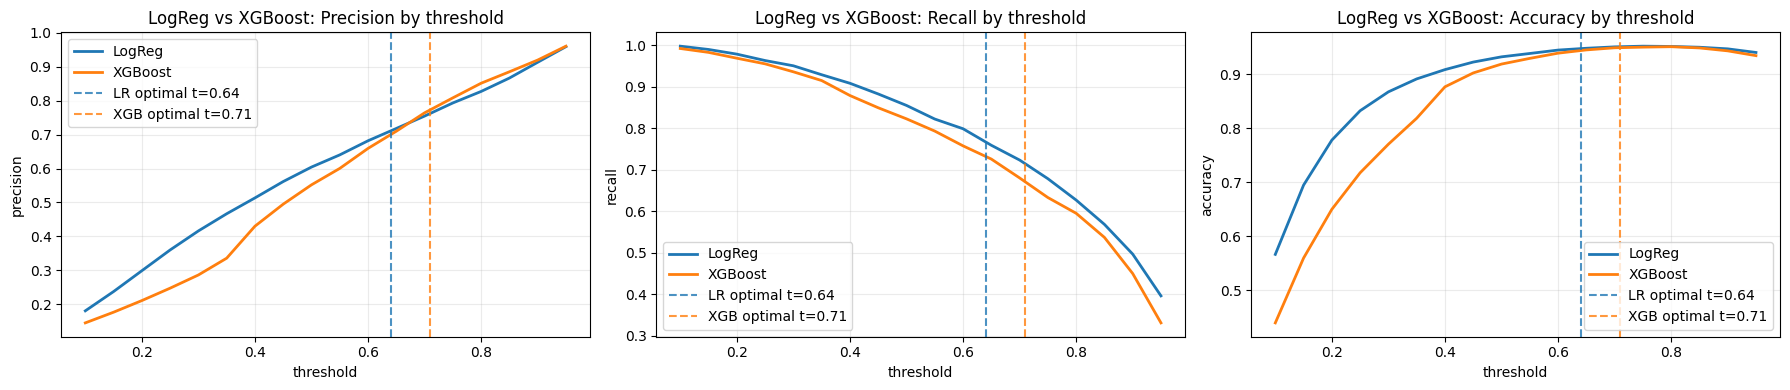

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

# --- Helper function ---
def pos_col(x):
    # Some models (like Logistic Regression) give probabilities like [[neg, pos]]
    # This just grabs the "positive class" (1) column only
    return x[:,1] if (x.ndim==2 and x.shape[1]==2) else x

#--- Metric Function ---
def metric_curve_vs_threshold(y_true, proba, thresholds=None):
    """Return precision, recall, accuracy arrays along a threshold grid."""
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.95, 18)  # 0.1 ~ 0.95
    P, R, A = [], [], []
    for t in thresholds:
      # Convert probabilities to 0/1 using the current threshold
        pred = (proba >= t).astype(int)

      # Calculate Precision, Recall, Accuracy at this threshold
        P.append(precision_score(y_true, pred, zero_division=0))
        R.append(recall_score(y_true, pred, zero_division=0))
        A.append(accuracy_score(y_true, pred))

    # Return everything as numpy arrays so it’s easy to plot later
    return thresholds, np.array(P), np.array(R), np.array(A)

# --- Prepare data ---
# Get positive-class probabilities for each model
p_lr  = pos_col(proba_lr_val)    # Logistic Regression validation probabilities
p_xgb = pos_col(proba_xgb_val)   # XGBoost validation probabilities

# --- Find the best threshold (F1-based)---
# This finds the threshold that gives the highest F1 score on validation data
t_lr,  f1_lr_best  = tune_threshold_for_f1(y_val, p_lr)
t_xgb, f1_xgb_best = tune_threshold_for_f1(y_val, p_xgb)

# --- Get metric curves for both models ---
thr, P_lr, R_lr, A_lr = metric_curve_vs_threshold(y_val, p_lr)
_,   P_xg, R_xg, A_xg = metric_curve_vs_threshold(y_val, p_xgb, thresholds=thr)

# --- Plot everything ---
# make 3 side-by-side plots: PRicision / Recall / Accuracy
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,4), sharex=True)


# --- Precision ---
axes[0].plot(thr, P_lr,  label="LogReg",  linewidth=2)
axes[0].plot(thr, P_xg,  label="XGBoost", linewidth=2)

# add vertical lines to show each model's best F1 threshold
axes[0].axvline(t_lr,  color="C0", linestyle="--", alpha=0.8, label=f"LR optimal t={t_lr:.2f}")
axes[0].axvline(t_xgb, color="C1", linestyle="--", alpha=0.8, label=f"XGB optimal t={t_xgb:.2f}")

axes[0].set_title("LogReg vs XGBoost: Precision by threshold")
axes[0].set_xlabel("threshold"); axes[0].set_ylabel("precision")
axes[0].grid(alpha=.25)

# remove duplicate legend labels (for cleaner legend)
handles, labels = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[0].legend(uniq.values(), uniq.keys())

# --- Recall ---
axes[1].plot(thr, R_lr,  label="LogReg",  linewidth=2)
axes[1].plot(thr, R_xg,  label="XGBoost", linewidth=2)

# show best F1 threshold lines for both models
axes[1].axvline(t_lr,  color="C0", linestyle="--", alpha=0.8, label=f"LR optimal t={t_lr:.2f}")
axes[1].axvline(t_xgb, color="C1", linestyle="--", alpha=0.8, label=f"XGB optimal t={t_xgb:.2f}")

axes[1].set_title("LogReg vs XGBoost: Recall by threshold")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("recall")
axes[1].grid(alpha=.25)

# clean up legend duplicates
handles, labels = axes[1].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[1].legend(uniq.values(), uniq.keys())

# --- Accuracy ---
axes[2].plot(thr, A_lr,  label="LogReg",  linewidth=2)
axes[2].plot(thr, A_xg,  label="XGBoost", linewidth=2)

axes[2].axvline(t_lr,  color="C0", linestyle="--", alpha=0.8, label=f"LR optimal t={t_lr:.2f}")
axes[2].axvline(t_xgb, color="C1", linestyle="--", alpha=0.8, label=f"XGB optimal t={t_xgb:.2f}")


axes[2].set_title("LogReg vs XGBoost: Accuracy by threshold")
axes[2].set_xlabel("threshold"); axes[2].set_ylabel("accuracy")
axes[2].grid(alpha=.25)

# avoid duplicate legend entries
handles, labels = axes[2].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[2].legend(uniq.values(), uniq.keys())


# --- Final Layout
# Adjust layout and show all plots together
plt.tight_layout()
plt.show()


> Confusion Matrix

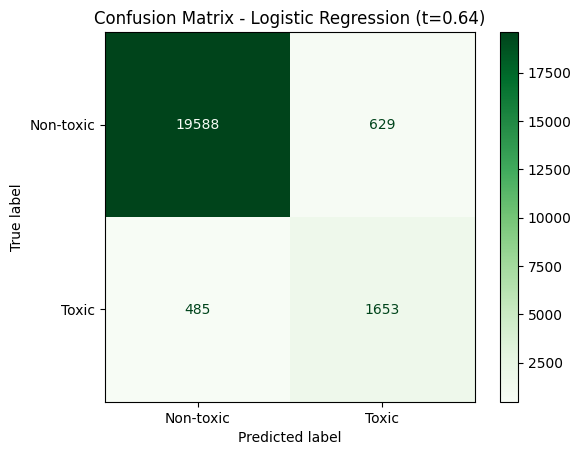

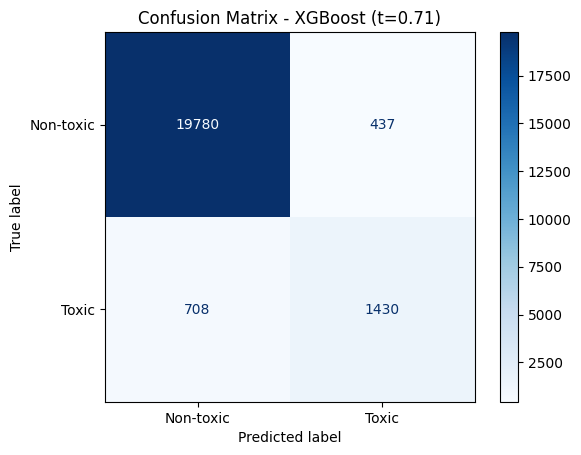

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Confusion Matrix
# --- Logistic Regression ---
pred_lr_test = (proba_lr_test >= t_lr).astype(int)
cm_lr = confusion_matrix(y_test, pred_lr_test)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Non-toxic", "Toxic"])
disp_lr.plot(cmap="Greens", values_format="d")
plt.title(f"Confusion Matrix - Logistic Regression (t={t_lr:.2f})")
plt.show()

# --- XGBoost ---
pred_xgb_test = (proba_xgb_test >= t_xgb).astype(int)
cm_xgb = confusion_matrix(y_test, pred_xgb_test)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Non-toxic", "Toxic"])
disp_xgb.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - XGBoost (t={t_xgb:.2f})")
plt.show()



PR/ROC Curves

AUC lr / xgb: 0.967739780167225 0.9472481411114109


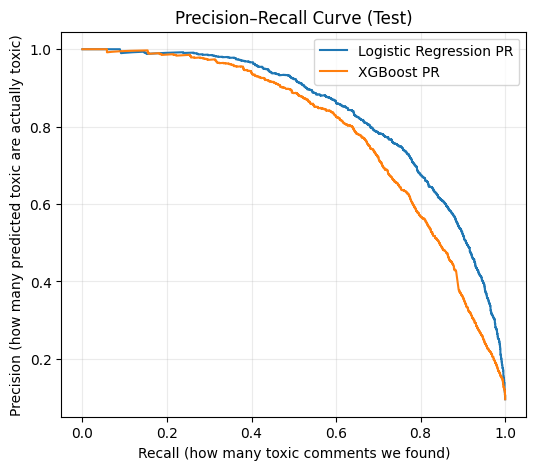

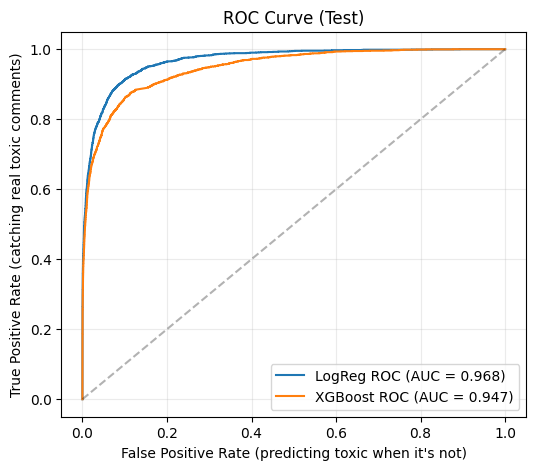

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Make sure test ordering matches y_test
test = test.reset_index(drop=True)

# Logistic (already fine in your run)
p_lr  = proba_lr_test.ravel()

# XGBoost: rebuild X_te from 'test' that matches y_test
X_te_plot  = tfidf.transform(test["comment_text"].fillna(""))
dtest_plot = xgb.DMatrix(X_te_plot)
p_xgb      = bst.predict(dtest_plot, iteration_range=(0, best_rounds)).ravel()

# Double-check they align
import numpy as np
y_true = np.asarray(y_test).astype(int).ravel()
assert p_xgb.shape == y_true.shape == p_lr.shape
print("AUC lr / xgb:", roc_auc_score(y_true, p_lr), roc_auc_score(y_true, p_xgb))

# PR
prec_lr, rec_lr, _ = precision_recall_curve(y_true, p_lr)
prec_xg, rec_xg, _ = precision_recall_curve(y_true, p_xgb)

plt.figure(figsize=(6,5))
plt.plot(rec_lr, prec_lr, label="Logistic Regression PR")
plt.plot(rec_xg, prec_xg, label="XGBoost PR")
plt.xlabel("Recall (how many toxic comments we found)")
plt.ylabel("Precision (how many predicted toxic are actually toxic)")
plt.title("Precision–Recall Curve (Test)")
plt.grid(alpha=.25); plt.legend(); plt.show()

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_true, p_lr)
fpr_xg, tpr_xg, _ = roc_curve(y_true, p_xgb)
auc_lr, auc_xg = auc(fpr_lr, tpr_lr), auc(fpr_xg, tpr_xg)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"LogReg ROC (AUC = {auc_lr:.3f})")
plt.plot(fpr_xg, tpr_xg, label=f"XGBoost ROC (AUC = {auc_xg:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=.3)
plt.xlabel("False Positive Rate (predicting toxic when it's not)")
plt.ylabel("True Positive Rate (catching real toxic comments)")
plt.title("ROC Curve (Test)")
plt.grid(alpha=.25); plt.legend(); plt.show()




#Model Save

In [ ]:
import joblib

# save
joblib.dump(bst_final, "xgb_final_model.pkl")
joblib.dump(tfidf_final, "tfidf_vectorizer.pkl")
joblib.dump(t_xgb, "threshold.pkl")   # tuned threshold save

# load
bst_loaded = joblib.load("xgb_final_model.pkl")
tfidf_loaded = joblib.load("tfidf_vectorizer.pkl")
t_loaded = joblib.load("threshold.pkl")
